# Chicago Crime Analysis
## Requête 1 - Data Exploration
**Auteure : Angelikia Kavuansiko**

**Problématique :** Comment les crimes à Chicago se distribuent-ils dans l'espace et dans le temps, et peut-on identifier des patterns récurrents pour mieux anticiper leur évolution ?

---

##  Imports

In [1]:
import pandas as pd
import plotly.express as px

##  Chargement du dataset

Le dataset Chicago Crime provient du portail open data de la ville de Chicago ([City of Chicago Data Portal](https://data.cityofchicago.org)).
Il contient les incidents criminels déclarés à Chicago, extraits du système CLEAR (Chicago Police Department).

La colonne `Date` est parsée en datetime pour permettre les analyses temporelles.

In [2]:
import sys
import pandas as pd

def load_data(limit=10000):

    url = (
        f"https://data.cityofchicago.org/resource/ijzp-q8t2.csv"
        f"?$limit={limit}"
        f"&$order=date%20DESC"
        f"&$where=latitude%20IS%20NOT%20NULL"
    )

    # Fix SSL uniquement sur Mac (Python 3.12 ne trouve pas les certificats système)
    if sys.platform == "darwin":
        import requests
        import io
        import certifi
        response = requests.get(url, verify=certifi.where())
        df = pd.read_csv(io.StringIO(response.text))
    else:
        df = pd.read_csv(url)

    # Renommage des colonnes (l'API retourne en minuscules)
    df = df.rename(columns={
        'latitude'            : 'Latitude',
        'longitude'           : 'Longitude',
        'primary_type'        : 'Primary Type',
        'arrest'              : 'Arrest',
        'date'                : 'Date',
        'location_description': 'Location Description',
        'domestic'            : 'Domestic',
        'beat'                : 'Beat',
        'ward'                : 'Ward',
        'fbi_code'            : 'FBI Code',
        'year'                : 'Year',
        'description'         : 'Description'
    })

    df["Date"] = pd.to_datetime(df["Date"], format="mixed")

    print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    return df

df = load_data()
print("Dataset chargé avec succès")
df.head()

Dataset chargé : 10000 lignes × 22 colonnes
Dataset chargé avec succès


,id,case_number,Date,block,iucr,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,community_area,FBI Code,x_coordinate,y_coordinate,Year,updated_on,Latitude,Longitude,location
0,14223030,JK286094,2026-06-08,036XX W DOUGLAS BLVD,0497,BATTERY,AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS ...,APARTMENT,False,True,...,24,29,04B,1152476,1893218,2026,2026-06-15T15:46:40.000,41.862851,-87.715755,"\n, \n(41.862850968, -87.715755)"
1,14223973,JK287246,2026-06-08,072XX S RICHMOND ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,18,66,08B,1157959,1856471,2026,2026-06-15T15:46:40.000,41.761902,-87.696627,"\n, \n(41.76190249, -87.696626851)"
2,14223471,JK286728,2026-06-08,076XX S MORGAN ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,17,71,07,1170965,1854265,2026,2026-06-15T15:46:40.000,41.755575,-87.649023,"\n, \n(41.755574885, -87.649022623)"
3,14224250,JK286700,2026-06-08,061XX N KIRKWOOD AVE,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,STREET,False,False,...,39,12,07,1145138,1940565,2026,2026-06-15T15:46:40.000,41.992917,-87.741493,"\n, \n(41.992917396, -87.741492591)"
4,14225502,JK287707,2026-06-08,040XX W DICKENS AVE,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,False,...,35,20,26,1148906,1913645,2026,2026-06-15T15:46:40.000,41.918975,-87.728331,"\n, \n(41.918974575, -87.728331482)"


##  Exploration complète du dataset

### Description des colonnes principales

| Colonne | Description |
|---|---|
| `Date` | Date et heure de l'incident |
| `Primary Type` | Type de crime (vol, agression, meurtre...) |
| `Description` | Description détaillée du crime |
| `Location Description` | Lieu de l'incident (rue, parking, école...) |
| `Arrest` | Arrestation effectuée (True/False) |
| `Beat` | Zone de patrouille de police |
| `Ward` | Circonscription électorale |
| `FBI Code` | Classification FBI du crime |
| `Latitude` | Latitude géographique |
| `Longitude` | Longitude géographique |

In [3]:
# Dimensions du dataset
print(f" Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

 Shape : 10,000 lignes × 22 colonnes


In [4]:
# Types de colonnes
print(" Types de données :")
print(df.dtypes)

 Types de données :
id                               int64
case_number                     object
Date                    datetime64[ns]
block                           object
iucr                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                            bool
Domestic                          bool
Beat                             int64
district                         int64
Ward                             int64
community_area                   int64
FBI Code                        object
x_coordinate                     int64
y_coordinate                     int64
Year                             int64
updated_on                      object
Latitude                       float64
Longitude                      float64
location                        object
dtype: object


In [5]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Manquantes": missing, "%": missing_pct})
print(" Valeurs manquantes :")
missing_df[missing_df["Manquantes"] > 0]

 Valeurs manquantes :


,Manquantes,%
Location Description,20,0.2


In [6]:
# Ranges
print(f" Période couverte : {df['Date'].min()} → {df['Date'].max()}")
print(f" Wards : {df['Ward'].dropna().astype(int).unique().tolist()}")
print(f" Types de crimes uniques : {df['Primary Type'].nunique()}")

 Période couverte : 2026-05-23 20:30:00 → 2026-06-08 00:00:00
 Wards : [24, 18, 17, 39, 35, 7, 31, 42, 44, 4, 10, 25, 16, 34, 2, 9, 3, 19, 5, 48, 13, 8, 26, 45, 41, 37, 22, 1, 27, 6, 20, 30, 28, 15, 47, 36, 46, 14, 33, 29, 23, 21, 12, 11, 43, 40, 50, 49, 38, 32]
 Types de crimes uniques : 28


In [7]:
# Stats descriptives
df.describe()

,id,Date,Beat,district,Ward,community_area,x_coordinate,y_coordinate,Year,Latitude,Longitude
count,1.000000e+04,10000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.0,10000.000000,10000.000000
mean,1.419741e+07,2026-05-31 09:56:41.856000,1142.830400,11.196500,22.725600,36.158300,1.165410e+06,1.887418e+06,2026.0,41.846656,-87.668480
min,2.916800e+04,2026-05-23 20:30:00,111.000000,1.000000,1.000000,1.000000,1.100317e+06,1.814512e+06,2026.0,41.645796,-87.906463
25%,1.421157e+07,2026-05-27 13:02:15,533.000000,5.000000,10.000000,23.000000,1.153950e+06,1.860752e+06,2026.0,41.773210,-87.710113
50%,1.421581e+07,2026-05-31 10:30:00,1111.000000,11.000000,23.000000,31.000000,1.167092e+06,1.894432e+06,2026.0,41.866132,-87.662475
75%,1.422004e+07,2026-06-04 08:01:15,1712.000000,17.000000,34.000000,53.000000,1.176885e+06,1.909216e+06,2026.0,41.906648,-87.626343
max,1.422818e+07,2026-06-08 00:00:00,2535.000000,25.000000,50.000000,77.000000,1.205116e+06,1.951492e+06,2026.0,42.022527,-87.524533
std,5.112256e+05,NaN,694.781548,6.942356,13.776018,21.118282,1.621230e+04,3.065780e+04,0.0,0.084314,0.059033


##  Requête 1a - Top 10 des types de crimes

On groupe les incidents par `Primary Type` et on compte le nombre d'occurrences pour identifier les crimes les plus fréquents à Chicago.

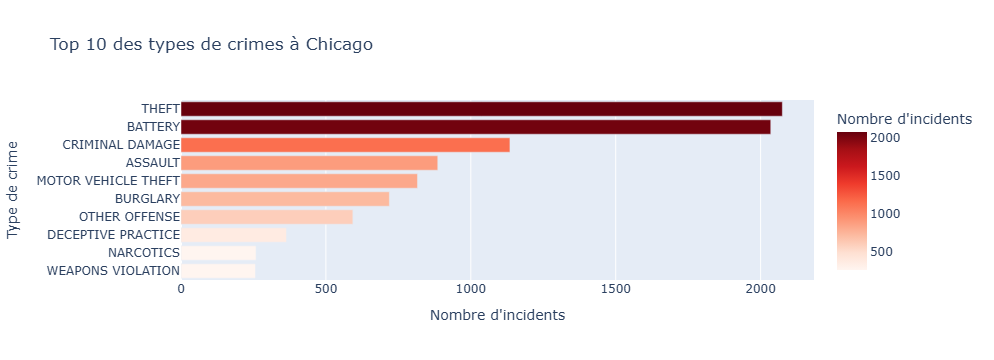

In [8]:
top10 = (
    df.groupby("Primary Type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

fig = px.bar(
    top10,
    x="count",
    y="Primary Type",
    orientation="h",
    title="Top 10 des types de crimes à Chicago",
    color="count",
    color_continuous_scale="reds",
    labels={"count": "Nombre d'incidents", "Primary Type": "Type de crime"}
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

##  Requête 1b - Taux d'arrestation par type de crime

On calcule le taux d'arrestation par type de crime en divisant le nombre d'arrestations par le nombre total d'incidents pour chaque catégorie."

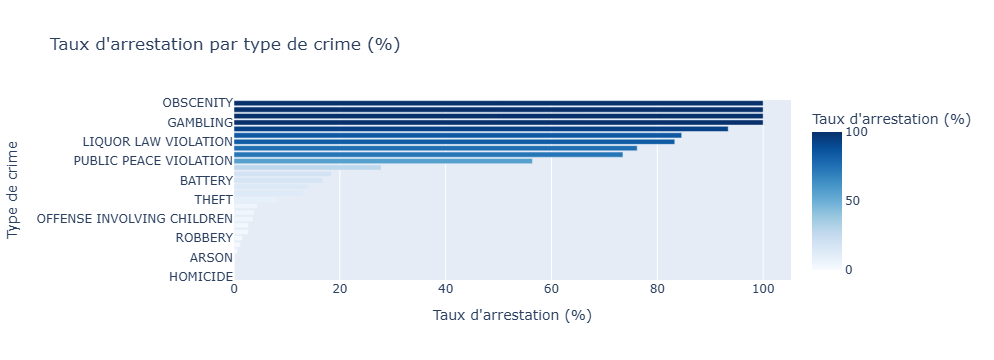

In [9]:
arrest_rate = (
    df.groupby("Primary Type")
    .agg(total=("Arrest", "count"), arrested=("Arrest", "sum"))
    .reset_index()
)
arrest_rate["taux"] = (arrest_rate["arrested"] / arrest_rate["total"] * 100).round(1)
arrest_rate = arrest_rate.sort_values("taux", ascending=False)

fig2 = px.bar(
    arrest_rate,
    x="taux",
    y="Primary Type",
    orientation="h",
    title="Taux d'arrestation par type de crime (%)",
    color="taux",
    color_continuous_scale="blues",
    labels={"taux": "Taux d'arrestation (%)", "Primary Type": "Type de crime"}
)
fig2.update_layout(yaxis={"categoryorder": "total ascending"})
fig2.show()

---
##  Synthèse de l'exploration

- Le dataset couvre plusieurs années de données criminelles à Chicago
- Les colonnes `Latitude` et `Longitude` sont complètes (filtrées à la source via l'API)
- La colonne `Date` est bien parsée en datetime → prête pour le forecasting (Léora)
- Les types de crimes les plus fréquents et le taux d'arrestation par type de crime sont identifiés